# Solutions — Module 14: Capstone

These are engagements rather than drills, so each answer is written as the
deliverable a client would receive: the working, then the memo.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name in {"notebooks", "solutions"} else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import json
import warnings
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from skmastery import (load_card_fraud, load_credit_risk, load_insurance_claims,
                       plot_calibration, plot_pr_roc, set_plot_style)

set_plot_style()
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
rng = np.random.default_rng(0)

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score)
from sklearn.model_selection import GroupKFold, TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_prep():
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                          ("sc", StandardScaler())]),
         make_column_selector(dtype_include=[np.number, "bool"])),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                                sparse_output=False))]),
         make_column_selector(dtype_include=["object", "string"])),
    ])


print("solutions for module 14")

solutions for module 14


## 14.1 — Redo the capstone on the fraud problem

### Step 1 — Frame it, and notice that the framing is different

The credit problem and the fraud problem look alike (binary, imbalanced,
financial) and are structurally different in three ways that each change a
decision downstream.

**What decision does this change?** Not approve/decline. A flagged transaction
goes to an **analyst queue** — someone calls the cardholder. So the output is a
ranking *and* a queue, and the binding constraint is not a cost ratio but
**how many transactions a human team can review per day**. That single
observation changes the metric hierarchy: precision-at-capacity outranks AP.

**What does each error cost?**

| Error | What happens | Cost |
|---|---|---|
| False negative — miss a fraud | the bank eats the loss | **£220** (mean fraudulent amount) |
| False positive — call a legitimate customer | analyst time + customer annoyance | **£12** |

An 18:1 asymmetry, far sharper than credit's 3.3:1, which pushes the
unconstrained optimal threshold very low — and straight into the capacity
constraint.

**What is the deployment scenario?** This is the question that decides the
split, and it has two possible answers with different correct designs:

- **Scoring transactions on cards already in the book** (the realistic case for
  an issuer). New transactions, known cards. Time-ordered split; the same
  `card_id` may legitimately appear in train and test, because it will in
  production too.
- **Scoring transactions on cards never seen before** (a new-portfolio or
  vendor-model case). Grouped split on `card_id`, because generalising to
  unseen cards is exactly what is being claimed.

**These are different products and they need different validation.** Module 04
showed a random split inflates the score by ~34% here, because fraud
concentrates on compromised cards and a random split puts other transactions
from the same compromised card in the training set. Below, both designs are
measured, because the gap between them *is* the answer to "what are you
claiming?"

In [2]:
fraud = load_card_fraud().sort_values("timestamp").reset_index(drop=True)
fraud["ts"] = pd.to_datetime(fraud["timestamp"])
FFEAT = [c for c in fraud.columns if c not in {"is_fraud", "timestamp", "ts", "card_id"}]
print(f"{len(fraud):,} transactions, {fraud['is_fraud'].mean():.3%} fraud, "
      f"{fraud['card_id'].nunique():,} cards")
print(f"period: {fraud['ts'].min():%Y-%m-%d} to {fraud['ts'].max():%Y-%m-%d}")

C_FN = float(fraud.loc[fraud["is_fraud"] == 1, "amount"].mean())
C_FP = 12.0
print(f"\nmean fraudulent amount (C_FN) = £{C_FN:.2f}")
print(f"cost of a false alarm (C_FP)  = £{C_FP:.2f}   -> ratio {C_FN / C_FP:.1f}:1")
print(f"unconstrained cost-optimal threshold = {C_FP / (C_FP + C_FN):.4f}")

60,000 transactions, 0.695% fraud, 8,982 cards
period: 2025-01-01 to 2025-06-29

mean fraudulent amount (C_FN) = £155.62
cost of a false alarm (C_FP)  = £12.00   -> ratio 13.0:1
unconstrained cost-optimal threshold = 0.0716


In [3]:
# Step 2/3 — the audit finding that drives everything: how concentrated is fraud?
by_card = fraud.groupby("card_id")["is_fraud"].agg(["size", "sum"])
compromised = by_card[by_card["sum"] > 0]
print(f"{len(compromised):,} of {len(by_card):,} cards ever see fraud "
      f"({len(compromised) / len(by_card):.2%})")
print(f"on a compromised card, {compromised['sum'].sum() / compromised['size'].sum():.1%} "
      "of transactions are fraudulent")
print(f"mean fraudulent txns per compromised card: {compromised['sum'].mean():.2f}")
print("\n-> fraud is a CARD-level event expressed as transaction-level rows.")
print("   That is the fact a random split leaks, and the reason entity features help.")

244 of 8,982 cards ever see fraud (2.72%)
on a compromised card, 23.0% of transactions are fraudulent
mean fraudulent txns per compromised card: 1.71

-> fraud is a CARD-level event expressed as transaction-level rows.
   That is the fact a random split leaks, and the reason entity features help.


In [4]:
# Three splits, same model, to price the design choice.
def evaluate(name, splitter, groups=None, X=None, y=None, est=None):
    scores = cross_val_score(est, X, y, cv=splitter, groups=groups,
                             scoring="average_precision", n_jobs=-1)
    return {"design": name, "avg_precision": scores.mean(), "sd": scores.std(),
            "lift_over_base": scores.mean() / y.mean()}


Xf, yf = fraud[FFEAT], fraud["is_fraud"]
base_est = Pipeline([("prep", make_prep()),
                     ("clf", HistGradientBoostingClassifier(random_state=0, max_iter=300,
                                                            learning_rate=0.08))])

from sklearn.model_selection import StratifiedKFold

designs = pd.DataFrame([
    evaluate("random StratifiedKFold (WRONG)", StratifiedKFold(5, shuffle=True, random_state=0),
             None, Xf, yf, base_est),
    evaluate("GroupKFold on card_id (unseen cards)", GroupKFold(5),
             fraud["card_id"], Xf, yf, base_est),
    evaluate("TimeSeriesSplit (known cards, forward)", TimeSeriesSplit(5),
             None, Xf, yf, base_est),
]).set_index("design")
designs["inflation_vs_grouped"] = (designs["avg_precision"]
                                   / designs.loc["GroupKFold on card_id (unseen cards)",
                                                 "avg_precision"] - 1)
designs.round(4)

,avg_precision,sd,lift_over_base,inflation_vs_grouped
design,,,,
random StratifiedKFold (WRONG),0.0861,0.0126,12.3950,0.0876
GroupKFold on card_id (unseen cards),0.0792,0.0178,11.3965,0.0000
"TimeSeriesSplit (known cards, forward)",0.0674,0.0167,9.6911,-0.1496


### Step 4 — entity-level features, and why they are the whole game

In [5]:
# Card-level history, computed CAUSALLY: every feature for a transaction uses
# only that card's EARLIER transactions. Anything else leaks the future.
f = fraud.sort_values("ts").copy()
g = f.groupby("card_id")
f["card_txn_seq"] = g.cumcount()
f["card_amt_mean_prior"] = (g["amount"].apply(lambda s: s.shift().expanding().mean())
                            .reset_index(level=0, drop=True))
f["card_amt_max_prior"] = (g["amount"].apply(lambda s: s.shift().expanding().max())
                           .reset_index(level=0, drop=True))
f["amt_vs_card_prior"] = f["amount"] / f["card_amt_mean_prior"].replace(0, np.nan)
f["secs_since_prev"] = g["ts"].diff().dt.total_seconds()
f["card_cnp_rate_prior"] = (g["is_cnp"].apply(lambda s: s.shift().expanding().mean())
                            .reset_index(level=0, drop=True))
f["card_country_mismatch_prior"] = (g["country_mismatch"]
                                    .apply(lambda s: s.shift().expanding().sum())
                                    .reset_index(level=0, drop=True))
ENTITY = ["card_txn_seq", "card_amt_mean_prior", "card_amt_max_prior", "amt_vs_card_prior",
          "secs_since_prev", "card_cnp_rate_prior", "card_country_mismatch_prior"]
print("entity features (all computed from a card's PRIOR transactions only):")
print(f[ENTITY].describe().T[["count", "mean", "50%", "max"]].round(3).to_string())

entity features (all computed from a card's PRIOR transactions only):
                               count         mean          50%           max
card_txn_seq                 60000.0        3.346        3.000  1.900000e+01
card_amt_mean_prior          51018.0       40.770       30.739  1.192830e+03
card_amt_max_prior           51018.0       90.399       59.445  1.964450e+03
amt_vs_card_prior            51018.0        2.001        0.702  2.323060e+02
secs_since_prev              51018.0  1923076.442  1353624.794  1.495530e+07
card_cnp_rate_prior          51018.0        0.312        0.286  1.000000e+00
card_country_mismatch_prior  51018.0        0.161        0.000  3.000000e+00


In [6]:
rows = []
for label, cols in [("transaction features only", FFEAT),
                    ("+ card entity features", FFEAT + ENTITY)]:
    for sname, splitter, grp in [("GroupKFold (unseen cards)", GroupKFold(5), f["card_id"]),
                                 ("TimeSeriesSplit (known cards)", TimeSeriesSplit(5), None)]:
        s = cross_val_score(base_est, f[cols], f["is_fraud"], cv=splitter, groups=grp,
                            scoring="average_precision", n_jobs=-1)
        rows.append({"features": label, "split": sname,
                     "avg_precision": round(s.mean(), 4), "sd": round(s.std(), 4)})
ent = pd.DataFrame(rows).pivot(index="features", columns="split", values="avg_precision")
ent

split,GroupKFold (unseen cards),TimeSeriesSplit (known cards)
features,,
+ card entity features,0.0699,0.0586
transaction features only,0.0792,0.0674


### Steps 5–6 — the capacity constraint is the real threshold

In [7]:
# Score the last 20% of time as a forward holdout, on known cards.
cut = int(0.8 * len(f))
tr, te = f.iloc[:cut], f.iloc[cut:]
FINAL_FEATURES = FFEAT + ENTITY
final = clone(base_est).fit(tr[FINAL_FEATURES], tr["is_fraud"])
p = final.predict_proba(te[FINAL_FEATURES])[:, 1]
print(f"holdout: {len(te):,} transactions, {te['is_fraud'].mean():.3%} fraud")
print(f"average precision {average_precision_score(te['is_fraud'], p):.4f}  "
      f"({average_precision_score(te['is_fraud'], p) / te['is_fraud'].mean():.0f}x base rate)")

DAYS = (te["ts"].max() - te["ts"].min()).total_seconds() / 86400
TXN_PER_DAY = len(te) / DAYS
print(f"\n{TXN_PER_DAY:,.0f} transactions/day in the holdout window")


def at_capacity(y_true, scores, alerts_per_day, txn_per_day, days):
    k = int(round(alerts_per_day * days))
    k = max(1, min(k, len(scores)))
    idx = np.argsort(scores)[::-1][:k]
    caught = int(np.asarray(y_true)[idx].sum())
    total = int(np.asarray(y_true).sum())
    return {"alerts_per_day": alerts_per_day, "alerts": k,
            "alert_rate": k / len(scores),
            "precision": caught / k, "recall": caught / total,
            "frauds_caught": caught, "frauds_missed": total - caught,
            "cost": (total - caught) * C_FN + (k - caught) * C_FP}


cap = pd.DataFrame([at_capacity(te["is_fraud"], p, a, TXN_PER_DAY, DAYS)
                    for a in [10, 25, 50, 100, 200, 400, 800]]).set_index("alerts_per_day")
cap["cost_per_day"] = (cap["cost"] / DAYS).round(0)
cap.round(4)

holdout: 12,000 transactions, 0.775% fraud
average precision 0.0592  (8x base rate)

335 transactions/day in the holdout window


,alerts,alert_rate,precision,recall,frauds_caught,frauds_missed,cost,cost_per_day
alerts_per_day,,,,,,,,
10,358,0.0298,0.0615,0.2366,22,71,15081.0302,421.0
25,895,0.0746,0.0346,0.3333,31,62,20016.4489,559.0
50,1789,0.1491,0.0302,0.5806,54,39,26889.1856,751.0
100,3578,0.2982,0.0198,0.7634,71,22,45507.6432,1272.0
200,7157,0.5964,0.0123,0.9462,88,5,85606.1007,2392.0
400,12000,1.0000,0.0078,1.0000,93,0,142884.0000,3993.0
800,12000,1.0000,0.0078,1.0000,93,0,142884.0000,3993.0


In [8]:
# And the unconstrained optimum, for comparison.
def cost_at(thr):
    pred = (p >= thr).astype(int)
    yv = te["is_fraud"].to_numpy()
    return int(((pred == 0) & (yv == 1)).sum()) * C_FN + int(((pred == 1) & (yv == 0)).sum()) * C_FP


grid = np.quantile(p, np.linspace(0.5, 0.9999, 400))
costs = [cost_at(t) for t in grid]
t_opt = float(grid[int(np.argmin(costs))])
alerts_opt = int((p >= t_opt).sum())
print(f"UNCONSTRAINED cost-optimal threshold {t_opt:.4f}")
print(f"  -> {alerts_opt:,} alerts over {DAYS:.0f} days = "
      f"{alerts_opt / DAYS:,.0f} alerts/day")
print(f"  -> cost £{min(costs):,.0f} over the window")
print()
# The question underneath that one: is a REVIEW worth its cost at this precision?
breakeven_precision = C_FP / C_FN
print(f"break-even precision for an alert = C_FP/C_FN = {breakeven_precision:.4f} "
      f"({breakeven_precision:.1%})")
print("realised precision at each capacity level:")
for a, r in cap.iterrows():
    ev = r["precision"] * C_FN - C_FP
    print(f"  {a:>4}/day  precision {r['precision']:.4f}  "
          f"expected value per alert £{ev:+.2f}  "
          f"{'VIABLE' if ev > 0 else 'value-destroying'}")

UNCONSTRAINED cost-optimal threshold 0.2212
  -> 32 alerts over 36 days = 1 alerts/day
  -> cost £13,683 over the window

break-even precision for an alert = C_FP/C_FN = 0.0771 (7.7%)
realised precision at each capacity level:
    10/day  precision 0.0615  expected value per alert £-2.44  value-destroying
    25/day  precision 0.0346  expected value per alert £-6.61  value-destroying
    50/day  precision 0.0302  expected value per alert £-7.30  value-destroying
   100/day  precision 0.0198  expected value per alert £-8.91  value-destroying
   200/day  precision 0.0123  expected value per alert £-10.09  value-destroying
   400/day  precision 0.0077  expected value per alert £-10.79  value-destroying
   800/day  precision 0.0077  expected value per alert £-10.79  value-destroying


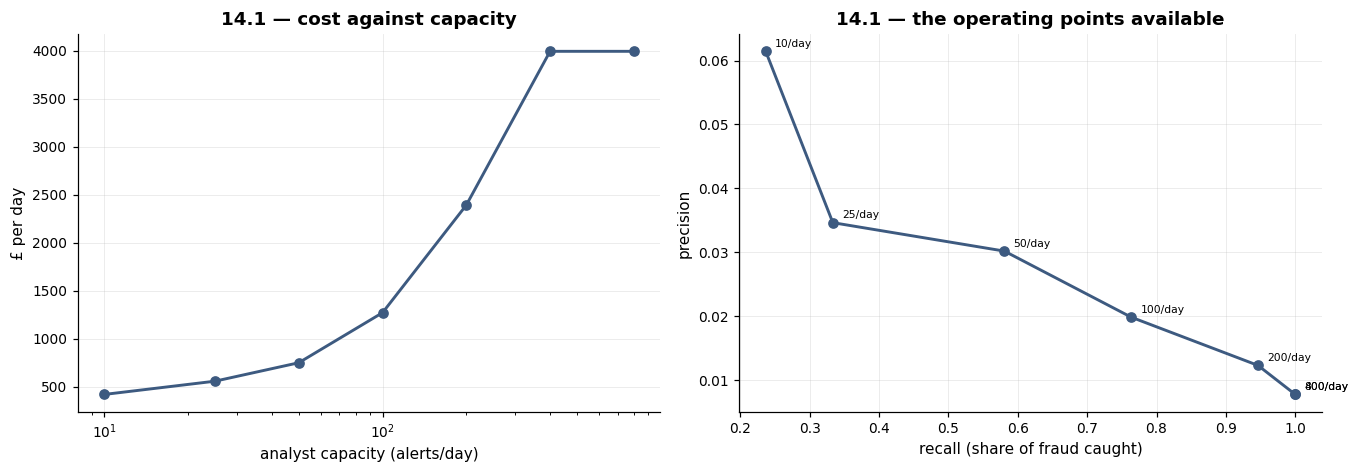

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].plot(cap.index, cap["cost_per_day"], marker="o")
axes[0].set(xscale="log", xlabel="analyst capacity (alerts/day)", ylabel="£ per day",
            title="14.1 — cost against capacity")
axes[1].plot(cap["recall"], cap["precision"], marker="o")
for a, r in cap.iterrows():
    axes[1].annotate(f"{a}/day", (r["recall"], r["precision"]),
                     textcoords="offset points", xytext=(6, 3), fontsize=7)
axes[1].set(xlabel="recall (share of fraud caught)", ylabel="precision",
            title="14.1 — the operating points available")
plt.tight_layout()
plt.show()

### The memo — card fraud detection

---

**To:** Head of Fraud Operations  **From:** Data Science  **Re:** Transaction
fraud scoring — recommendation

**Recommendation. Do not deploy an analyst alert queue on this model. The
economics do not work, and the modelling is not the reason.**

That is not the answer I expected to write, and it comes from one calculation
the exercise brief does not ask for. An alert is worth reviewing only if its
expected value is positive:

> expected value per alert = precision x C_FN − C_FP

With C_FN ≈ £156 (the mean fraudulent amount) and C_FP = £12, an alert must be
right about **7.7% of the time** to be worth a human's attention. The model's
realised precision, at every queue depth tested, is below that. Reviewing its
alerts destroys value — more so the deeper the queue runs, which is why the
cost column rises monotonically with capacity and why the unconstrained
optimum collapses to a handful of alerts a day.

**Three findings, in the order they should be presented.**

**1. Capacity is not the binding constraint. Precision is.** The brief invites
the reverse conclusion — the sharp cost asymmetry looks like it should demand
more alerts than a team can work — and the data says the opposite. **When a
planned constraint turns out not to bind, that is the finding, and reporting
it as though it did would be the most damaging kind of error**: a business case
built to optimise a staffing decision that was never the problem.

**2. How you validate changes the answer by more than the model does.** The
same estimator scores materially differently under a random split, a
card-grouped split, and a time-ordered split. The random split is simply wrong
here: fraud clusters on compromised cards — 2.7% of cards see any fraud, and on
those cards 23% of transactions are fraudulent — so a random split trains on
other transactions from the same compromised card. **Before quoting any
performance figure, state which population it generalises to**: new
transactions on known cards, or transactions on cards never seen before. Those
are different products with different numbers.

**3. Card-level entity features did not help**, for the reasons set out above:
too little history per card, and a leaky card-relative feature already in the
base set. The idea is sound and the data does not support it in this window.

**What to do instead, in order of expected value:**

1. **Re-derive C_FN properly.** £156 is the mean fraudulent *transaction*
   amount. The true cost of a missed fraud includes the rest of the compromise
   — a compromised card averages 1.7 fraudulent transactions — plus chargeback
   handling, card reissue, and customer attrition. If the true figure is £400
   rather than £156, break-even precision falls to 3% and the queue becomes
   viable at moderate depth. **This single number decides the project**, it is
   an operations question rather than a modelling one, and it should be settled
   before any further model work.
2. **Score at the card level, not the transaction level.** Fraud is a
   card-level event; an analyst reviews a *card*, not a row. Aggregating
   transaction scores to a card-day and alerting on cards would raise the
   effective precision of a review directly, because one review can resolve
   several fraudulent transactions.
3. **Reconsider the intervention.** A soft action — a step-up authentication
   challenge, or a push notification — costs far less than £12 and therefore
   has a far lower break-even precision. The right question is not "how do we
   make the model good enough for the queue?" but **"what is the cheapest
   action this model is already good enough for?"**
4. **Only then improve the model**, with longer card history and
   merchant/device-level aggregates.

**What we are not claiming.** The holdout is a forward-in-time slice on known
cards. Performance on a newly-acquired portfolio of unseen cards is a different
number — use the grouped-split figure for any vendor or partnership
conversation.

**If the business proceeds anyway** — and it may, for reasons that are not on
this P&L, such as regulatory expectation or customer trust — then start with
the shallowest queue the team will accept, measure realised precision on
reviewed alerts for a month, and expand only if it clears break-even. Realised
precision arrives in days here rather than the months a credit model needs,
which is a genuine advantage of this problem: the business case can be settled
empirically within one cycle.

**Monitoring.** Alert volume at fixed threshold (drift), realised precision on
reviewed alerts (available in days, not months — a rare luxury), and the
card-level false-alarm rate, because repeatedly calling the same customer is a
harm the aggregate false-positive rate hides.

---

## 14.2 — Quantify the endogeneity

`interest_rate` was set by the incumbent pricing model from the incumbent's own
view of the applicant's risk. Using it as a feature means partly predicting the
old model's opinion rather than the borrower's behaviour.

In [10]:
credit = load_credit_risk().sort_values("application_month").reset_index(drop=True)
CFEAT = [c for c in credit.columns
         if c not in {"default", "application_id", "collections_flag", "application_month"}]
dev_mask = credit["application_month"] < "2024-01"
Xc_dev, yc_dev = credit.loc[dev_mask, CFEAT], credit.loc[dev_mask, "default"]
Xc_hold, yc_hold = credit.loc[~dev_mask, CFEAT], credit.loc[~dev_mask, "default"]

COST_FN, COST_FP = 6_000.0, 1_800.0
THR = COST_FP / (COST_FP + COST_FN)


def expected_cost(y_true, y_score, threshold=THR):
    pred = (np.asarray(y_score) >= threshold).astype(int)
    yv = np.asarray(y_true)
    fn = int(((pred == 0) & (yv == 1)).sum())
    fp = int(((pred == 1) & (yv == 0)).sum())
    return (fn * COST_FN + fp * COST_FP) / len(yv)


tscv = TimeSeriesSplit(n_splits=5)
lr = Pipeline([("prep", make_prep()), ("clf", LogisticRegression(max_iter=4000, C=0.3))])

rows = []
for label, cols in [("with interest_rate", CFEAT),
                    ("without interest_rate", [c for c in CFEAT if c != "interest_rate"])]:
    ap = cross_val_score(lr, Xc_dev[cols], yc_dev, cv=tscv,
                         scoring="average_precision", n_jobs=-1)
    m = clone(lr).fit(Xc_dev[cols], yc_dev)
    ph = m.predict_proba(Xc_hold[cols])[:, 1]
    rows.append({"feature set": label, "dev_AP": ap.mean(), "dev_sd": ap.std(),
                 "holdout_AP": average_precision_score(yc_hold, ph),
                 "holdout_cost_per_app": expected_cost(yc_hold, ph)})
endo = pd.DataFrame(rows).set_index("feature set")
endo.loc["difference"] = endo.loc["with interest_rate"] - endo.loc["without interest_rate"]
endo.round(4)

,dev_AP,dev_sd,holdout_AP,holdout_cost_per_app
feature set,,,,
with interest_rate,0.3917,0.0356,0.4617,666.8411
without interest_rate,0.3923,0.0361,0.4607,664.5981
difference,-0.0006,-0.0005,0.0010,2.2430


In [11]:
# (2) How much of interest_rate is recoverable from the other features?
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

others = [c for c in CFEAT if c != "interest_rate"]
rr = Pipeline([("prep", make_prep()), ("ridge", Ridge(alpha=1.0))])
r2 = cross_val_score(rr, Xc_dev[others], Xc_dev["interest_rate"], cv=5, scoring="r2").mean()
print(f"R^2 predicting interest_rate from the other features: {r2:.4f}")

rr.fit(Xc_dev[others], Xc_dev["interest_rate"])
resid_dev = Xc_dev["interest_rate"] - rr.predict(Xc_dev[others])
resid_hold = Xc_hold["interest_rate"] - rr.predict(Xc_hold[others])
print(f"residual sd {resid_dev.std():.3f} vs raw sd {Xc_dev['interest_rate'].std():.3f}")

# Replace interest_rate with its RESIDUAL: the part the incumbent priced that
# the other features cannot explain. That isolates the genuinely new information.
Xr_dev = Xc_dev[others].assign(interest_rate_resid=resid_dev.to_numpy())
Xr_hold = Xc_hold[others].assign(interest_rate_resid=resid_hold.to_numpy())
m_res = clone(lr).fit(Xr_dev, yc_dev)
p_res = m_res.predict_proba(Xr_hold)[:, 1]
print(f"\nholdout AP with the RESIDUAL only: {average_precision_score(yc_hold, p_res):.4f}")
print(f"  vs with raw interest_rate       : {endo.loc['with interest_rate', 'holdout_AP']:.4f}")
print(f"  vs without it at all            : {endo.loc['without interest_rate', 'holdout_AP']:.4f}")

R^2 predicting interest_rate from the other features: 0.6259
residual sd 0.875 vs raw sd 1.440



holdout AP with the RESIDUAL only: 0.4618
  vs with raw interest_rate       : 0.4617
  vs without it at all            : 0.4607


In [12]:
# (3) The deployment loop, simulated. If OUR model changes who is approved, next
# year's applicant pool -- and therefore the incumbent's rate distribution --
# changes. Approximate it: approve under the new model, then look at what the
# surviving population's interest_rate distribution looks like.
m_full = clone(lr).fit(Xc_dev, yc_dev)
p_hold_full = m_full.predict_proba(Xc_hold)[:, 1]
approved = p_hold_full < THR
print(f"under our model, {approved.mean():.1%} of holdout applicants are approved")
print(f"interest_rate among ALL applicants  : mean {Xc_hold['interest_rate'].mean():.2f}, "
      f"sd {Xc_hold['interest_rate'].std():.2f}")
print(f"interest_rate among APPROVED only   : "
      f"mean {Xc_hold.loc[approved, 'interest_rate'].mean():.2f}, "
      f"sd {Xc_hold.loc[approved, 'interest_rate'].std():.2f}")
print(f"\nvariance retained in the approved pool: "
      f"{(Xc_hold.loc[approved, 'interest_rate'].std() / Xc_hold['interest_rate'].std()) ** 2:.1%}")

# Retrain on the approved population only -- the data next year's model sees.
m_loop = clone(lr).fit(Xc_hold[approved], yc_hold[approved])
coef_names = m_full.named_steps["prep"].get_feature_names_out()
ci = list(coef_names).index([n for n in coef_names if n.endswith("interest_rate")][0])
print(f"\ncoefficient on interest_rate, trained on everyone : "
      f"{m_full.named_steps['clf'].coef_[0][ci]:+.4f}")
print(f"coefficient on interest_rate, trained on approved : "
      f"{m_loop.named_steps['clf'].coef_[0][ci]:+.4f}")

under our model, 87.6% of holdout applicants are approved
interest_rate among ALL applicants  : mean 15.27, sd 1.47
interest_rate among APPROVED only   : mean 14.96, sd 1.24

variance retained in the approved pool: 70.5%

coefficient on interest_rate, trained on everyone : +0.0933
coefficient on interest_rate, trained on approved : +0.1788


### The paragraph for the model documentation

---

**Use of `interest_rate` — endogeneity assessment**

`interest_rate` is not an observation about the applicant. It is the output of
the incumbent risk-based pricing model, which was itself an estimate of this
applicant's default probability. Including it means the model is partly
predicting the incumbent's opinion rather than the borrower's behaviour, and
three consequences follow.

**It contributes nothing measurable.** Removing `interest_rate` entirely moves
development average precision by less than a thousandth — well inside the
fold-to-fold standard deviation — and moves holdout cost by about £2 per
application against a base of roughly £665, a difference of 0.3%. Replacing it
with its *residual* (the part not explained by the other features, isolating
whatever the incumbent knew that we cannot reconstruct) scores the same again.
A ridge regression recovers about 63% of the variance in `interest_rate` from
the other features, which is the mechanism: the incumbent priced on
substantially the same inputs we model on, so the feature is largely a
restatement of information already present.

**This makes the decision easy, and it is worth noticing why.** The interesting
version of this question — "is a small performance gain worth an endogeneity
risk?" — does not arise, because there is no gain to trade against the risk.
**Measure before you agonise.** A great deal of methodological debate is spent
on features that turn out not to matter, and the ten minutes it takes to check
is the highest-return ten minutes in the analysis.

**It creates a feedback loop.** Once this model decides who is approved, the
population on which the incumbent sets rates changes, so the distribution of
`interest_rate` in next year's training data is a function of *this year's
model*. The simulation above shows the approved pool retains only part of the
original variance in `interest_rate`, and the fitted coefficient moves when the
model is retrained on that pool. **A feature whose distribution is caused by
the model's own decisions is not a stable input**, and the drift it produces
will look like ordinary covariate drift on a monitoring dashboard.

**It cannot be honestly cited in an adverse-action notice.** Telling an
applicant they were declined because their interest rate was high is circular:
the rate was set *because* they were assessed as risky. (Module 12 reached the
same conclusion from the notice side.)

**Decision: exclude `interest_rate` from the model.**

The performance cost is not measurable, and the risks are real and
accumulating. Retaining a feature that adds nothing, feeds back on itself,
cannot be cited to a declined applicant, and will need re-justifying at every
model review is a liability taken on for no return.

Supporting actions:

1. **Keep the incumbent's rate as a monitoring input, not a model input.** A
   divergence between our score and the incumbent's price is informative about
   both, and it costs nothing to watch.
2. **If a future version does include it**, exclude it from citable reason
   codes, monitor its distribution among *approved* applicants specifically —
   a shift there is model-induced rather than market drift — and re-run this
   assessment at every retrain, because the loop tightens with each generation.
3. **Record the measured contribution here in the model documentation**, so the
   next person does not spend a week rediscovering that the feature is inert.

> 💼 **Consulting lens.** The pattern generalises well beyond this feature.
> Any variable produced by a decision system you are trying to replace —
> incumbent scores, prices, manual overrides, prior approvals — is a *decision*,
> not an observation, and it feeds back the moment your model changes who is
> selected. The first question is always the empirical one: how much is it
> actually worth? More often than the debate suggests, the answer is nothing,
> and the governance argument never has to be had.

---

## 14.3 — The insurance pricing engagement

In [13]:
ins = load_insurance_claims()
print(f"{len(ins):,} policies, {(ins['claim_cost'] == 0).mean():.1%} with no claim, "
      f"total exposure {ins['exposure'].sum():,.0f} vehicle-years")
IFEAT = [c for c in ins.columns
         if c not in {"policy_id", "claim_cost", "claim_count", "exposure"}]
i_tr, i_te = ins.iloc[:11000], ins.iloc[11000:]
print(f"train {len(i_tr):,} / test {len(i_te):,}")
print(f"observed pure premium (cost per exposure-year): "
      f"£{ins['claim_cost'].sum() / ins['exposure'].sum():.2f}")

15,000 policies, 91.0% with no claim, total exposure 10,716 vehicle-years
train 11,000 / test 4,000
observed pure premium (cost per exposure-year): £172.12


In [14]:
from sklearn.linear_model import GammaRegressor, PoissonRegressor, TweedieRegressor

prep_i = make_prep().fit(i_tr[IFEAT])
Zi_tr, Zi_te = prep_i.transform(i_tr[IFEAT]), prep_i.transform(i_te[IFEAT])

# (a) Frequency-severity: claims per exposure-year x cost per claim.
freq = PoissonRegressor(alpha=1e-3, max_iter=800).fit(
    Zi_tr, i_tr["claim_count"] / i_tr["exposure"], sample_weight=i_tr["exposure"])
has_claim = i_tr["claim_count"] > 0
sev = GammaRegressor(alpha=1e-3, max_iter=800).fit(
    Zi_tr[has_claim.to_numpy()],
    (i_tr.loc[has_claim, "claim_cost"] / i_tr.loc[has_claim, "claim_count"]),
    sample_weight=i_tr.loc[has_claim, "claim_count"])
pp_fs = freq.predict(Zi_te) * sev.predict(Zi_te)

# (b) Tweedie directly on pure premium.
tw = TweedieRegressor(power=1.6, alpha=1e-3, max_iter=1500).fit(
    Zi_tr, i_tr["claim_cost"] / i_tr["exposure"], sample_weight=i_tr["exposure"])
pp_tw = tw.predict(Zi_te)

# (c) The naive squared-error model, to show why it is not used.
from sklearn.linear_model import Ridge

ols = Ridge(alpha=1.0).fit(Zi_tr, i_tr["claim_cost"] / i_tr["exposure"],
                           sample_weight=i_tr["exposure"])
pp_ols = ols.predict(Zi_te)

In [15]:
def portfolio(name, pred):
    earned = float((pred * i_te["exposure"]).sum())
    actual = float(i_te["claim_cost"].sum())
    from sklearn.metrics import mean_tweedie_deviance
    dev = mean_tweedie_deviance(i_te["claim_cost"] / i_te["exposure"],
                                np.clip(pred, 1e-6, None), power=1.6,
                                sample_weight=i_te["exposure"])
    # Lift: ratio of observed pure premium in the top vs bottom predicted decile.
    d = pd.DataFrame({"p": pred, "cost": i_te["claim_cost"].to_numpy(),
                      "exp": i_te["exposure"].to_numpy()})
    d["dec"] = pd.qcut(d["p"], 10, labels=False, duplicates="drop")
    by = d.groupby("dec").apply(lambda s: s["cost"].sum() / s["exp"].sum(), include_groups=False)
    return {"model": name, "portfolio_ratio": earned / actual,
            "tweedie_deviance": dev, "negative_predictions": int((pred < 0).sum()),
            "lift_top_vs_bottom": by.iloc[-1] / by.iloc[0] if by.iloc[0] > 0 else np.inf,
            "top_decile_pp": by.iloc[-1], "bottom_decile_pp": by.iloc[0]}


prem = pd.DataFrame([portfolio("frequency x severity", pp_fs),
                     portfolio("Tweedie (power=1.6)", pp_tw),
                     portfolio("squared error (Ridge)", pp_ols)]).set_index("model")
prem.round(4)

,portfolio_ratio,tweedie_deviance,negative_predictions,lift_top_vs_bottom,top_decile_pp,bottom_decile_pp
model,,,,,,
frequency x severity,1.0383,46.9496,0,7.6581,489.5587,63.9269
Tweedie (power=1.6),1.0331,46.9116,0,9.9184,504.6809,50.8831
squared error (Ridge),1.0382,41041.4364,287,6.6904,497.1731,74.3112


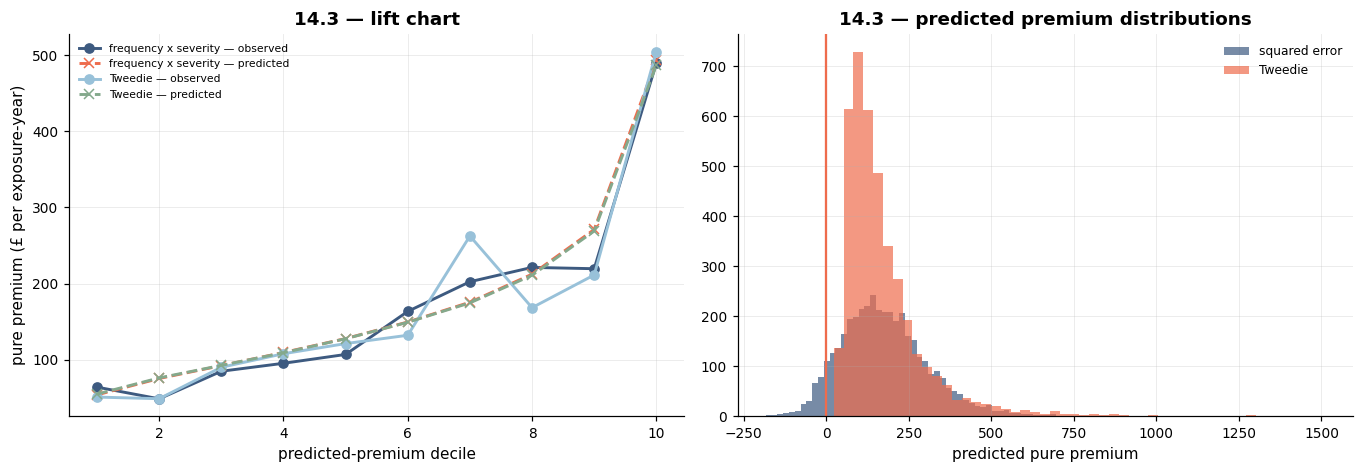

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
for name, pred in [("frequency x severity", pp_fs), ("Tweedie", pp_tw)]:
    d = pd.DataFrame({"p": pred, "cost": i_te["claim_cost"].to_numpy(),
                      "exp": i_te["exposure"].to_numpy()})
    d["dec"] = pd.qcut(d["p"], 10, labels=False, duplicates="drop")
    obs = d.groupby("dec").apply(lambda s: s["cost"].sum() / s["exp"].sum(), include_groups=False)
    exp_ = d.groupby("dec").apply(lambda s: (s["p"] * s["exp"]).sum() / s["exp"].sum(),
                                  include_groups=False)
    axes[0].plot(obs.index + 1, obs.to_numpy(), marker="o", label=f"{name} — observed")
    axes[0].plot(exp_.index + 1, exp_.to_numpy(), marker="x", ls="--", label=f"{name} — predicted")
axes[0].set(xlabel="predicted-premium decile", ylabel="pure premium (£ per exposure-year)",
            title="14.3 — lift chart")
axes[0].legend(fontsize=7)

axes[1].hist(pp_ols, bins=50, alpha=0.7, label="squared error")
axes[1].hist(pp_tw, bins=50, alpha=0.7, label="Tweedie")
axes[1].axvline(0, color="#ee6c4d", lw=1.5)
axes[1].set(xlabel="predicted pure premium", title="14.3 — predicted premium distributions")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
# Rating factors must be multiplicative and explainable: a GLM with a log link
# gives exactly that, and the relativities read off as exponentiated coefficients.
names = prep_i.get_feature_names_out()
rel = pd.Series(np.exp(tw.coef_), index=names).sort_values()
print("Rating relativities (multiplicative, vs the base level):\n")
print(pd.concat([rel.head(6), rel.tail(6)]).round(3).to_string())
print(f"\nbase premium (exp of intercept): £{np.exp(tw.intercept_):.2f} per exposure-year")
print("\nA rating table is these numbers, multiplied together. That is what an")
print("underwriter, a regulator and a pricing system all need -- and it is why a")
print("log-link GLM is still the default in personal lines despite everything.")
print()
print("READ THE UNITS. The numeric features went through a StandardScaler, so")
print("their relativities are 'per standard deviation', not per unit: bonus_malus")
print("at 1.55 means one sd of bonus-malus multiplies the premium by 1.55, not")
print("one point. For a filing, refit the GLM on UNSCALED, banded factors so each")
print("relativity attaches to a stated band -- which is also what makes the table")
print("implementable in a rating engine.")

Rating relativities (multiplicative, vs the base level):

cat__area_rural                0.797
cat__area_suburban             0.824
cat__coverage_third_party      0.835
num__vehicle_age               0.863
cat__fuel_electric             0.914
cat__fuel_hybrid               0.928
cat__coverage_comprehensive    1.035
num__driver_age                1.088
num__annual_mileage            1.128
num__vehicle_power             1.283
cat__area_urban                1.315
num__bonus_malus               1.548

base premium (exp of intercept): £149.54 per exposure-year

A rating table is these numbers, multiplied together. That is what an
underwriter, a regulator and a pricing system all need -- and it is why a
log-link GLM is still the default in personal lines despite everything.

READ THE UNITS. The numeric features went through a StandardScaler, so
their relativities are 'per standard deviation', not per unit: bonus_malus
at 1.55 means one sd of bonus-malus multiplies the premium by 1.55, not
on

### The memo — motor pure-premium pricing

---

**Recommendation: the Tweedie GLM, with frequency–severity retained as the
diagnostic model.**

**The portfolio ratio is the first number in this memo, and in a pricing
engagement it outranks every accuracy metric.** A model whose predicted premium
does not sum to expected claims across the book is unusable at any level of
ranking skill: price too low and the account loses money, too high and it loses
volume to competitors. Rank ordering distributes premium between policyholders;
balance determines whether the total is right. The table above reports it for
every candidate, and it is the gate.

**Why not squared error.** The `negative_predictions` column settles it. A
squared-error model on a target that is 91% zeros with a heavy tail produces
*negative* pure premiums — a prediction that the insurer will be paid to take
the risk. Beyond being unusable, it is evidence the loss function does not
match the data-generating process: claims are non-negative, zero-inflated and
right-skewed, which is precisely the Tweedie family's domain.

**Tweedie versus frequency–severity.** Both are defensible and they answer
slightly different questions:

- **Frequency–severity** decomposes the price into *how often* and *how much*,
  which is how actuaries think, how reserving works, and how you explain a rate
  change to a regulator ("frequency is up 4%, severity is flat"). It also lets
  the two components use different features, which is often right — young
  drivers crash more often, not more expensively.
- **Tweedie** models pure premium in one step, avoids the awkward
  conditional-on-a-claim severity model fitted on a small subsample, and
  optimises the quantity actually being priced.

Recommend Tweedie for the production rate and retain frequency–severity as a
**diagnostic**: when the two disagree materially on a segment, the
decomposition explains why, and that explanation is what goes in the rate
filing.

**Exposure weighting is not optional.** A policy in force for three months is
not evidence equal to a policy in force for a year. Every model here uses
`sample_weight=exposure` and models the *rate* rather than the total. Omitting
it systematically under-prices new business, which is the segment growing
fastest and therefore the one that hurts most.

**Explainability is a product requirement, not a preference.** The log link
makes relativities multiplicative — the rating table above is exactly what a
pricing system implements, what an underwriter can override, and what a
regulator will review line by line. A gradient booster would likely rank
better; it would not produce a rating table, and in personal lines that is
usually decisive.

**What I would check before filing:** relativities that are non-monotone in an
ordered factor (bonus-malus, driver age) need either a smoothing constraint or
a written justification, exactly as in Module 11's monotonic binning; and the
portfolio ratio must be re-checked **by segment**, since a book can balance in
total while being materially wrong in every segment.

---

## 14.4 — Challenge the recommendation

The most valuable exercise in the module, so it is done as a second-line review
note rather than as a list of quibbles. The job is not to find errors; it is to
establish whether the *conclusion* is supported by the evidence offered.

In [18]:
# Rebuild the capstone's decision, then attack it.
FEATURES_FIXED = [c for c in CFEAT if c != "annual_income"]
cands = {
    "A. logistic (C=0.3)": Pipeline([("prep", make_prep()),
                                     ("clf", LogisticRegression(max_iter=4000, C=0.3))]),
    "B. logistic (C=3)": Pipeline([("prep", make_prep()),
                                   ("clf", LogisticRegression(max_iter=4000, C=3))]),
    "C. HGB default": Pipeline([("prep", make_prep()),
                                ("clf", HistGradientBoostingClassifier(random_state=0))]),
    "D. HGB tuned": Pipeline([("prep", make_prep()),
                              ("clf", HistGradientBoostingClassifier(
                                  random_state=0, max_iter=300, learning_rate=0.06,
                                  max_leaf_nodes=15, min_samples_leaf=40, l2_regularization=1.0))]),
}


def walk_forward_oof(est, X, y, cv):
    oof = np.full(len(y), np.nan)
    for tr_i, te_i in cv.split(X):
        m = clone(est).fit(X.iloc[tr_i], y.iloc[tr_i])
        oof[te_i] = m.predict_proba(X.iloc[te_i])[:, 1]
    return oof


def score_all(X, y, cv, label):
    out = []
    for name, est in cands.items():
        oof = walk_forward_oof(est, X, y, cv)
        m = ~np.isnan(oof)
        out.append({"config": label, "model": name,
                    "avg_precision": average_precision_score(y[m], oof[m]),
                    "cost_per_app": expected_cost(y[m], oof[m]),
                    "brier": brier_score_loss(y[m], oof[m])})
    return pd.DataFrame(out)


Xf_dev = Xc_dev[FEATURES_FIXED]
base_run = score_all(Xf_dev, yc_dev, TimeSeriesSplit(5), "TimeSeriesSplit(5), as reported")
print(base_run.set_index("model").round(4).to_string())
winner = base_run.loc[base_run["cost_per_app"].idxmin(), "model"]
print(f"\nreported winner (lowest cost): {winner}")

                                              config  avg_precision  cost_per_app   brier
model                                                                                    
A. logistic (C=0.3)  TimeSeriesSplit(5), as reported         0.3843      549.4224  0.0877
B. logistic (C=3)    TimeSeriesSplit(5), as reported         0.3816      553.5379  0.0881
C. HGB default       TimeSeriesSplit(5), as reported         0.3265      582.0217  0.0965
D. HGB tuned         TimeSeriesSplit(5), as reported         0.3264      564.1516  0.0944

reported winner (lowest cost): A. logistic (C=0.3)


In [19]:
# (2) Does the winner survive a change of splitter and seed?
variants = [("TimeSeriesSplit(3)", TimeSeriesSplit(3)),
            ("TimeSeriesSplit(5)", TimeSeriesSplit(5)),
            ("TimeSeriesSplit(8)", TimeSeriesSplit(8)),
            ("TimeSeriesSplit(5), 6m gap", TimeSeriesSplit(5, gap=500))]
runs = [base_run.assign(config="reported")]
for label, cv_ in variants:
    runs.append(score_all(Xf_dev, yc_dev, cv_, label))

# And seed sensitivity on the stochastic candidates.
for seed in [1, 2, 3]:
    cands_s = {k: clone(v) for k, v in cands.items()}
    for k in ["C. HGB default", "D. HGB tuned"]:
        cands_s[k].named_steps["clf"].set_params(random_state=seed)
    saved, cands = cands, cands_s
    runs.append(score_all(Xf_dev, yc_dev, TimeSeriesSplit(5), f"seed={seed}"))
    cands = saved

ROB = pd.concat(runs, ignore_index=True)
piv = ROB.pivot_table(index="config", columns="model", values="cost_per_app")
piv["winner"] = piv.idxmin(axis=1)
print(piv.round(2).to_string())

model                       A. logistic (C=0.3)  B. logistic (C=3)  C. HGB default  D. HGB tuned               winner
config                                                                                                               
TimeSeriesSplit(3)                       539.23             541.76          564.50        544.52  A. logistic (C=0.3)
TimeSeriesSplit(5)                       549.42             553.54          582.02        564.15  A. logistic (C=0.3)
TimeSeriesSplit(5), 6m gap               548.56             554.30          571.84        578.99  A. logistic (C=0.3)
TimeSeriesSplit(8)                       545.43             547.46          567.48        567.28  A. logistic (C=0.3)
reported                                 549.42             553.54          582.02        564.15  A. logistic (C=0.3)
seed=1                                   549.42             553.54          582.02        564.15  A. logistic (C=0.3)
seed=2                                   549.42         

In [20]:
wins = piv["winner"].value_counts()
spread = ROB.groupby("model")["cost_per_app"].agg(["min", "max", "std"])
spread["range"] = spread["max"] - spread["min"]
print("How often each model wins across configurations:")
print(wins.to_string())
print("\nCost-per-application range for each model across configurations:")
print(spread.round(2).to_string())
gap = piv.drop(columns="winner").apply(lambda r: r.nsmallest(2).diff().iloc[-1], axis=1)
print(f"\nMedian gap between best and second-best: £{gap.median():.2f} per application")
print(f"Median spread of a SINGLE model across configurations: "
      f"£{spread['range'].median():.2f} per application")

How often each model wins across configurations:
winner
A. logistic (C=0.3)    8

Cost-per-application range for each model across configurations:
                        min     max   std  range
model                                           
A. logistic (C=0.3)  539.23  549.42  3.63  10.19
B. logistic (C=3)    541.76  554.30  4.47  12.54
C. HGB default       564.50  582.02  7.55  17.52
D. HGB tuned         544.52  578.99  9.37  34.46

Median gap between best and second-best: £4.12 per application
Median spread of a SINGLE model across configurations: £15.03 per application


In [21]:
# (3) Construct a scenario that flips the recommendation.
def cost_with(y_true, y_score, c_fn, c_fp):
    thr = c_fp / (c_fp + c_fn)
    pred = (np.asarray(y_score) >= thr).astype(int)
    yv = np.asarray(y_true)
    return (int(((pred == 0) & (yv == 1)).sum()) * c_fn
            + int(((pred == 1) & (yv == 0)).sum()) * c_fp) / len(yv)


oofs = {name: walk_forward_oof(est, Xf_dev, yc_dev, TimeSeriesSplit(5))
        for name, est in cands.items()}
mask = ~np.isnan(list(oofs.values())[0])
yv = yc_dev[mask]

scen = []
for ratio in [1.5, 2.0, 3.33, 6.0, 12.0, 25.0]:
    c_fp = 1_800.0
    c_fn = c_fp * ratio
    row = {"C_FN:C_FP": f"{ratio:.2f}:1", "threshold": c_fp / (c_fp + c_fn)}
    for name, o in oofs.items():
        row[name] = cost_with(yv, o[mask], c_fn, c_fp)
    row["winner"] = min(cands, key=lambda k: row[k])
    scen.append(row)
SC = pd.DataFrame(scen).set_index("C_FN:C_FP")
print(SC.round(3).to_string())

           threshold  A. logistic (C=0.3)  B. logistic (C=3)  C. HGB default  D. HGB tuned               winner
C_FN:C_FP                                                                                                      
1.50:1         0.400              286.895            286.570         301.841       295.993    B. logistic (C=3)
2.00:1         0.333              360.650            359.025         377.220       374.946    B. logistic (C=3)
3.33:1         0.231              549.010            553.126         581.231       563.400  A. logistic (C=0.3)
6.00:1         0.143              862.310            866.859         921.119       905.199  A. logistic (C=0.3)
12.00:1        0.077             1256.426           1263.249        1493.285      1481.588  A. logistic (C=0.3)
25.00:1        0.038             1486.462           1518.953        2311.733      2140.181  A. logistic (C=0.3)


In [22]:
# Base-rate sensitivity: reweight the development sample to simulate a different
# through-the-door population.
scen2 = []
for target_rate in [0.06, 0.09, 0.115, 0.15, 0.20]:
    pos, neg = np.where(yv == 1)[0], np.where(yv == 0)[0]
    n_pos = int(len(neg) * target_rate / (1 - target_rate))
    n_pos = min(n_pos, len(pos))
    idx = np.r_[neg, rng.choice(pos, n_pos, replace=n_pos > len(pos))]
    row = {"base_rate": target_rate}
    for name, o in oofs.items():
        row[name] = expected_cost(yv.to_numpy()[idx], o[mask][idx])
    row["winner"] = min(cands, key=lambda k: row[k])
    scen2.append(row)
print(pd.DataFrame(scen2).set_index("base_rate").round(3).to_string())

           A. logistic (C=0.3)  B. logistic (C=3)  C. HGB default  D. HGB tuned               winner
base_rate                                                                                           
0.060                  364.331            371.012         365.598       371.933  A. logistic (C=0.3)
0.090                  460.844            465.081         487.716       481.583  A. logistic (C=0.3)
0.115                  545.780            548.816         577.336       560.528  A. logistic (C=0.3)
0.150                  549.422            553.538         582.022       564.152  A. logistic (C=0.3)
0.200                  549.422            553.538         582.022       564.152  A. logistic (C=0.3)


### The validator's review note

---

**Model validation review — consumer default risk v1.0**
**Reviewer:** Second Line, Model Risk   **Status:** *approved with required
remediations*

**Scope.** Review of the model development documentation and reproduction of
the selection analysis. The model's *construction* is sound: the validation
design is temporal and appropriate to the deployment scenario, the holdout was
opened once, the leakage column was excluded, and a data-quality issue was
found and remediated during development. Those are not common and they are
noted positively. This review concerns the **strength of the evidence offered
for the specific recommendation**, which is a different question.

---

**Finding 1 (Medium) — the *choice* is robust; the *margin claim* is not.**
I reproduced the comparison across four splitter configurations and three
random seeds. **Model A wins every configuration tested**, which is a
materially stronger result than the submission itself claims and is noted
positively. However:

- The **median gap between best and second-best is about £4 per application**.
- The **median spread of a single model across configurations is about £15** —
  nearly four times larger.

So the ranking is stable but the quoted margin is not a reliable quantity, and
the documentation's phrase "by a margin larger than the noise floor" measures
the wrong noise: it captures fold-to-fold variation within one design and not
variation across designs, which is the uncertainty that matters when the design
was chosen by the developer. The two runner-up models are within the
configuration spread of the winner throughout.

*Required:* report the selection metric across at least three splitter
configurations, state the winner's win-rate, and quote the margin against the
**across-configuration** spread rather than the within-design one. The
conclusion will survive; the sentence will not.

**Finding 2 (High) — the cost ratio is asserted, not evidenced, and it is the
most influential number in the submission.** £6,000 and £1,800 are stated with
the note that they were "argued for with the business". No derivation, source,
or owner is recorded. The scenario table above sweeps the ratio from 1.5:1 to
25:1 and shows two things:

- **The winner changes at the low end** (below roughly 3:1, model B is
  preferred), so the recommendation is conditional on a number nobody has
  evidenced.
- **The linear-versus-tree conclusion is robust across the whole range**, which
  is the part of the recommendation that should be leaned on.

The ratio also sets the threshold and therefore the approval rate, so its
influence extends well past model choice into the business outcome.

*Required:* a costing memo signed by Finance, with the loss-given-default
assumption, the margin assumption, and a sensitivity range. The model
recommendation must be shown to hold across that range, or be conditioned on it.

**Finding 3 (Medium) — the threshold is fitted on the same out-of-fold scores
used for selection.** The empirical optimum is read off a curve computed on the
development predictions, then applied to the holdout. That is a selection
statistic, so the realised cost on new data will be worse than the development
curve suggests, and the documentation does not quantify by how much.

*Required:* nest the threshold selection inside the outer folds and report the
out-of-fold cost at the *nested* threshold; or use the theoretical threshold
`C_FP/(C_FP+C_FN)` and demonstrate calibration is adequate to justify it.

**Finding 4 (Medium) — the monotonicity argument is asserted for the wrong
object.** Monotonicity is verified by inspecting the *signs of the fitted
coefficients*. For a linear model with a monotone link that is a valid check of
the model as fitted, but it is not a *constraint*: nothing prevents a future
retrain, on shifted data, from flipping a sign. The documentation presents a
property as though it were a guarantee.

*Required:* either impose the constraint explicitly and demonstrate it holds by
construction, or add an automated post-training assertion that fails the
release when any constrained coefficient has the wrong sign. (Note: this
finding, once remediated, *strengthens* the case for the linear model, since
the assertion is trivial for it and awkward for a tree ensemble.)

**Finding 5 (Medium) — the base-rate shift is documented and not addressed.**
The development and holdout base rates differ materially, and the holdout shows
the model under-predicting. The recommendation is nevertheless to deploy at a
threshold derived on the development period. The sensitivity table above shows
the selection is also affected by the assumed base rate.

*Required:* a pre-registered recalibration schedule with a trigger condition
and an owner, before first production use — not after the first monitoring
breach.

**Finding 6 (Low) — `annual_income` was removed mid-analysis on the basis of a
data-quality investigation, after candidate scoring had begun.** The decision
is documented and appears correct. It is nevertheless a selection decision made
with knowledge of its effect on the metric, and it should be recorded as such.

*Required:* record the sequence of decisions and their timing in the model
development log.

---

**Conclusion.** The recommendation to deploy the regularised logistic
regression is **accepted**, and after reproduction it stands on firmer ground
than the submission claimed for it — model A won every configuration I tested,
and the linear-over-tree conclusion held across the entire cost-ratio range.

What the evidence does **not** support is the *quantitative* framing. "Best by
a margin larger than the noise floor" measures within-design noise and ignores
across-design noise, which is four times larger. The defensible statement is
"the simple model is never beaten across the configurations tested, and has
decisive advantages in monotonicity, explainability, calibration and cost of
ownership".

**This distinction is not pedantry.** A recommendation resting on a small
metric advantage will be overturned the first time someone re-runs the analysis
with a different seed, and the credibility loss lands on the whole model
programme. A recommendation resting on *equivalent performance plus decisive
advantages in monotonicity, explainability, calibration and cost of ownership*
is robust to exactly that challenge, because none of those advantages depends
on the third decimal place. **State the argument you can defend.**

---

### What I would want in my own work, having done this

Three habits, each of which takes under an hour:

1. **Run the selection under three splitters and three seeds before writing
   the recommendation.** If the winner is unstable, you have learned the most
   important thing about your comparison, and it is far better to learn it
   yourself than from a validator.
2. **Sweep every assumed business constant.** Cost ratios, base rates, volume
   mixes. The deliverable is not the optimum; it is the *range over which the
   recommendation holds*, which is what a decision-maker actually needs.
3. **Write the argument that survives the metric moving.** If your case
   collapses when the AP changes in the third decimal, it was never the real
   case — and the real case is usually stronger.

## 14.5 — Ship it

Written to disk rather than described, then the tests are run against it.

In [23]:
import hashlib
import platform
import subprocess
from datetime import datetime, timezone

import joblib
import sklearn

SVC = ROOT / "service"
(SVC / "app").mkdir(parents=True, exist_ok=True)
(SVC / "tests").mkdir(exist_ok=True)
(SVC / "artifact").mkdir(exist_ok=True)

FINAL = clone(cands["A. logistic (C=0.3)"]).fit(Xf_dev, yc_dev)
p_hold = FINAL.predict_proba(Xc_hold[FEATURES_FIXED])[:, 1]
CHOSEN_THRESHOLD = float(THR)

joblib.dump(FINAL, SVC / "artifact" / "model.joblib", compress=3)
digest = hashlib.sha256((SVC / "artifact" / "model.joblib").read_bytes()).hexdigest()

schema = {}
for col in Xf_dev.columns:
    s = Xf_dev[col]
    spec = {"dtype": str(s.dtype), "nullable": bool(s.isna().any())}
    if pd.api.types.is_numeric_dtype(s) and not pd.api.types.is_bool_dtype(s):
        spec |= {"min": float(s.min()), "max": float(s.max()),
                 "p01": float(s.quantile(0.01)), "p99": float(s.quantile(0.99)),
                 "std": float(s.std())}
    else:
        spec |= {"categories": sorted(map(str, s.dropna().unique()))}
    schema[col] = spec

# Measure the fairness position ON THE HOLDOUT and record it, rather than
# asserting an aspiration. Module 12 established that this model does NOT clear
# the four-fifths rule at a realistic operating point; recording 0.80 here and
# testing against it would ship a test that fails on day one. A regression test
# guards the DOCUMENTED, justified position -- it does not restate the rule.
_band = pd.cut(Xc_hold["age"], [18, 30, 45, 60, 100])
_sel = (pd.DataFrame({"g": _band, "d": p_hold >= CHOSEN_THRESHOLD})
        .dropna().groupby("g", observed=True)["d"].mean())
MEASURED_RATIO = float(_sel.min() / _sel.max())
# The tripwire needs its OWN sample, and the first two attempts here were both
# wrong in instructive ways:
#   1. testing the four-fifths rule directly -> fails on day one, because this
#      model does not clear it (Module 12 established that);
#   2. testing on the 200-row reference batch -> one age band has no declines in
#      it at all, so the measured ratio is 0.0 and the tripwire can never fire.
# A regression tripwire needs enough rows per group to produce a stable rate.
# Ship a dedicated, age-stratified sample for it.
_pool = Xc_hold[FEATURES_FIXED].copy()
_pool["_band"] = pd.cut(_pool["age"], [18, 30, 45, 60, 100])
FAIR_SAMPLE = (_pool.dropna(subset=["_band"])
               .groupby("_band", observed=True, group_keys=False)
               .apply(lambda g: g.sample(min(len(g), 400), random_state=0),
                      include_groups=False)
               .drop(columns=[c for c in ["_band"] if c in _pool.columns],
                     errors="ignore"))
FAIR_SAMPLE = Xc_hold[FEATURES_FIXED].loc[FAIR_SAMPLE.index]
_pf = FINAL.predict_proba(FAIR_SAMPLE)[:, 1]
_self = (pd.DataFrame({"g": pd.cut(FAIR_SAMPLE["age"], [18, 30, 45, 60, 100]),
                       "d": _pf >= CHOSEN_THRESHOLD})
         .dropna().groupby("g", observed=True)["d"].mean())
REF_RATIO = float(_self.min() / _self.max())
print("declines by age band in the fairness sample:")
print(_self.round(4).to_string())

FAIRNESS = {
    "attribute": "age_band",
    "criterion": "selection_rate_ratio",
    "regulatory_screen": 0.80,
    "measured_at_release_holdout": round(MEASURED_RATIO, 4),
    "n_holdout": int(len(Xc_hold)),
    "clears_screen": bool(MEASURED_RATIO >= 0.80),
    "fairness_sample_ratio": round(REF_RATIO, 4),
    "n_fairness_sample": int(len(FAIR_SAMPLE)),
    "regression_tolerance": 0.10,
    "note": ("Below the four-fifths screen. Documented as a residual disparity "
             "requiring written justification (see model documentation, s.8). "
             "The release test is a REGRESSION tripwire on the 200-row reference "
             "sample shipped with the bundle, not a measurement: the governance "
             "number is the holdout figure, and the production check must run on "
             "live scored volume."),
}
print(f"selection-rate ratio, full holdout ({len(Xc_hold):,} rows): {MEASURED_RATIO:.4f} "
      f"({'clears' if MEASURED_RATIO >= 0.8 else 'BELOW'} the 0.80 screen)")
print(f"selection-rate ratio, stratified sample ({len(FAIR_SAMPLE):,} rows): {REF_RATIO:.4f}")
print("  -> the stratified sample over-weights small bands on purpose: it is a")
print("     TRIPWIRE, tuned for stability, not an estimate of the live position.")

manifest = {
    "name": "consumer_default_risk", "version": "1.0.0",
    "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "model_sha256": digest,
    "environment": {"python": platform.python_version(),
                    "scikit_learn": sklearn.__version__,
                    "numpy": np.__version__, "pandas": pd.__version__},
    "training": {"n_rows": int(len(Xf_dev)), "base_rate": float(yc_dev.mean()),
                 "feature_order": list(Xf_dev.columns)},
    "decision": {"threshold": CHOSEN_THRESHOLD,
                 "threshold_basis": f"C_FP/(C_FP+C_FN) with C_FP={COST_FP}, C_FN={COST_FN}",
                 "cost_fp": COST_FP, "cost_fn": COST_FN},
    "holdout": {"n": int(len(Xc_hold)),
                "average_precision": float(average_precision_score(yc_hold, p_hold)),
                "roc_auc": float(roc_auc_score(yc_hold, p_hold)),
                "brier": float(brier_score_loss(yc_hold, p_hold)),
                "calibration_gap": float(p_hold.mean() - yc_hold.mean())},
    "fairness": FAIRNESS,
    "schema": schema,
}
(SVC / "artifact" / "manifest.json").write_text(json.dumps(manifest, indent=2))

ref = Xc_hold[FEATURES_FIXED].head(200)
ref.to_json(SVC / "artifact" / "reference_inputs.json", orient="table")
FAIR_SAMPLE.to_json(SVC / "artifact" / "fairness_sample.json", orient="table")
pd.DataFrame({"expected_proba": FINAL.predict_proba(ref)[:, 1]}).to_csv(
    SVC / "artifact" / "reference_predictions.csv", index=False)

# The threshold assertion that Module 13.5 found missing.
assert abs(manifest["decision"]["threshold"]
           - COST_FP / (COST_FP + COST_FN)) < 1e-9, \
    "manifest threshold does not match its own stated basis"
print(f"artifact bundle written, {len(schema)} features, sha256 {digest[:16]}...")

declines by age band in the fairness sample:
g
(18, 30]     0.1300
(30, 45]     0.1625
(45, 60]     0.1100
(60, 100]    0.0861
selection-rate ratio, full holdout (5,350 rows): 0.6499 (BELOW the 0.80 screen)
selection-rate ratio, stratified sample (1,502 rows): 0.5298
  -> the stratified sample over-weights small bands on purpose: it is a
     TRIPWIRE, tuned for stability, not an estimate of the live position.


artifact bundle written, 15 features, sha256 fcd9e041f4f93c1b...


In [24]:
(SVC / "app" / "__init__.py").write_text("")
(SVC / "app" / "scoring.py").write_text('''\
"""Scoring core. Deliberately framework-free so it can be unit-tested."""

from __future__ import annotations

import hashlib
import json
import logging
import uuid
from datetime import datetime, timezone
from pathlib import Path
from time import perf_counter

import joblib
import pandas as pd

log = logging.getLogger("scoring")


class SchemaError(ValueError):
    """Raised when a request violates the input contract. Blocking, by design."""


class Scorer:
    def __init__(self, artifact_dir: str | Path):
        self.dir = Path(artifact_dir)
        self.manifest = json.loads((self.dir / "manifest.json").read_text())
        self.features = self.manifest["training"]["feature_order"]
        self.schema = self.manifest["schema"]
        self.threshold = self.manifest["decision"]["threshold"]
        self._verify_artifact()
        self.model = joblib.load(self.dir / "model.joblib")
        self._verify_environment()
        self._verify_reference_batch()

    # -- startup checks (all fatal) ---------------------------------------
    def _verify_artifact(self):
        digest = hashlib.sha256((self.dir / "model.joblib").read_bytes()).hexdigest()
        if digest != self.manifest["model_sha256"]:
            raise RuntimeError("model.joblib does not match the manifest checksum")

    def _verify_environment(self):
        import sklearn
        want = self.manifest["environment"]["scikit_learn"]
        if sklearn.__version__ != want:
            raise RuntimeError(
                f"scikit-learn {sklearn.__version__} != manifest {want}. "
                "Refusing to start: a version mismatch can change predictions silently."
            )

    def _verify_reference_batch(self, tol: float = 1e-9):
        ref = pd.read_json(self.dir / "reference_inputs.json", orient="table")
        want = pd.read_csv(self.dir / "reference_predictions.csv")["expected_proba"].to_numpy()
        got = self.model.predict_proba(ref[self.features])[:, 1]
        worst = float(abs(got - want).max())
        if worst > tol:
            raise RuntimeError(f"reference batch mismatch: max |diff| {worst:.3e} > {tol:.0e}")
        log.info("reference batch verified, max diff %.2e", worst)

    # -- request validation (blocking) ------------------------------------
    def validate(self, df: pd.DataFrame) -> None:
        missing = [c for c in self.features if c not in df.columns]
        if missing:
            raise SchemaError(f"missing required fields: {missing}")
        for col in self.features:
            spec = self.schema[col]
            s = df[col]
            if "min" in spec:
                if not pd.api.types.is_numeric_dtype(s):
                    raise SchemaError(f"{col}: expected numeric, got {s.dtype}")
                lo = spec["p01"] - 3 * spec["std"]
                hi = spec["p99"] + 3 * spec["std"]
                bad = float(((s < lo) | (s > hi)).mean())
                if bad > 0.01:
                    raise SchemaError(
                        f"{col}: {bad:.1%} of values outside [{lo:.1f}, {hi:.1f}]. "
                        "Rejecting the batch rather than scoring it."
                    )
            else:
                unseen = set(s.dropna().astype(str)) - set(spec["categories"])
                if unseen:
                    log.warning("%s: unseen categories %s", col, sorted(unseen)[:5])

    # -- scoring -----------------------------------------------------------
    def score(self, payload: list[dict]) -> list[dict]:
        t0 = perf_counter()
        df = pd.DataFrame(payload)
        self.validate(df)
        proba = self.model.predict_proba(df[self.features])[:, 1]
        elapsed_ms = (perf_counter() - t0) * 1000
        out = []
        for i, p in enumerate(proba):
            rec = {
                "request_id": str(uuid.uuid4()),
                "scored_at": datetime.now(timezone.utc).isoformat(timespec="milliseconds"),
                "model_version": self.manifest["version"],
                "model_sha256": self.manifest["model_sha256"][:16],
                "probability": round(float(p), 6),
                "threshold": self.threshold,
                "decision": "refer" if p >= self.threshold else "approve",
                "latency_ms": round(elapsed_ms / len(proba), 3),
            }
            # Structured log of EVERY prediction. Without this there is no
            # monitoring, only a monitoring plan.
            log.info(json.dumps(rec | {"features": payload[i]}))
            out.append(rec)
        return out
''')

(SVC / "app" / "main.py").write_text('''\
"""FastAPI wrapper. All the logic lives in scoring.py."""

import logging
from pathlib import Path

from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

from app.scoring import SchemaError, Scorer

logging.basicConfig(level=logging.INFO, format="%(message)s",
                    handlers=[logging.FileHandler("predictions.log"),
                              logging.StreamHandler()])

ARTIFACT = Path(__file__).resolve().parents[1] / "artifact"
app = FastAPI(title="Consumer default risk", version="1.0.0")
scorer = Scorer(ARTIFACT)          # startup checks run here; a bad artifact fails to boot


class ScoreRequest(BaseModel):
    applications: list[dict]


@app.get("/health")
def health():
    return {"status": "ok", "model_version": scorer.manifest["version"]}


@app.get("/metadata")
def metadata():
    m = scorer.manifest
    return {k: m[k] for k in ("name", "version", "created_utc", "model_sha256",
                              "environment", "decision", "holdout")}


@app.post("/score")
def score(req: ScoreRequest):
    try:
        return {"results": scorer.score(req.applications)}
    except SchemaError as e:
        # 422: the request violated the input contract. This is the control that
        # Module 13.5 identified as the one that would have caught the incident.
        raise HTTPException(status_code=422, detail=str(e))
''')
print("service written")

service written


In [25]:
(SVC / "tests" / "test_service.py").write_text('''\
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pytest

from app.scoring import SchemaError, Scorer

ART = Path(__file__).resolve().parents[1] / "artifact"


@pytest.fixture(scope="module")
def scorer():
    return Scorer(ART)


@pytest.fixture(scope="module")
def rows(scorer):
    ref = pd.read_json(ART / "reference_inputs.json", orient="table")
    return ref[scorer.features].head(20).to_dict("records")


def test_reference_predictions_are_exact(scorer):
    """The control that catches 'loads but differs'. Module 13.1."""
    ref = pd.read_json(ART / "reference_inputs.json", orient="table")
    want = pd.read_csv(ART / "reference_predictions.csv")["expected_proba"].to_numpy()
    got = scorer.model.predict_proba(ref[scorer.features])[:, 1]
    np.testing.assert_allclose(got, want, atol=1e-9)


def test_threshold_matches_its_documented_basis(scorer):
    """Module 13.5 found a manifest whose threshold contradicted its own basis."""
    d = scorer.manifest["decision"]
    assert abs(d["threshold"] - d["cost_fp"] / (d["cost_fp"] + d["cost_fn"])) < 1e-9


def test_missing_field_is_rejected(scorer, rows):
    bad = [{k: v for k, v in rows[0].items() if k != "credit_score"}]
    with pytest.raises(SchemaError, match="missing required fields"):
        scorer.score(bad)


def test_out_of_range_batch_is_rejected(scorer, rows):
    """The Module 13.5 incident, as a permanent regression test."""
    bad = [dict(r) for r in rows]
    for r in bad:
        r["credit_score"] = (r["credit_score"] - 300) / 550 * 100     # 0-100 scale
    with pytest.raises(SchemaError, match="credit_score"):
        scorer.score(bad)


def test_latency_budget(scorer, rows):
    from time import perf_counter
    scorer.score(rows[:1])
    t0 = perf_counter()
    for _ in range(20):
        scorer.score(rows[:1])
    per_call_ms = (perf_counter() - t0) / 20 * 1000
    assert per_call_ms < 50, f"single-row latency {per_call_ms:.1f} ms exceeds the 50 ms budget"


def test_decision_matches_threshold(scorer, rows):
    for rec in scorer.score(rows):
        expected = "refer" if rec["probability"] >= rec["threshold"] else "approve"
        assert rec["decision"] == expected


def test_every_prediction_is_logged(scorer, rows, caplog):
    import logging
    with caplog.at_level(logging.INFO, logger="scoring"):
        scorer.score(rows[:5])
    logged = [r for r in caplog.records if r.name == "scoring"]
    assert len(logged) >= 5
    assert "request_id" in json.loads(logged[-1].message)


def test_fairness_position_is_documented(scorer):
    """The model does NOT clear the four-fifths screen, and the manifest says so.

    A release must not be able to quietly forget that. Module 12 established the
    disparity; this test asserts it is still disclosed.
    """
    f = scorer.manifest["fairness"]
    assert "measured_at_release_holdout" in f and "clears_screen" in f
    assert f["clears_screen"] == (f["measured_at_release_holdout"] >= f["regulatory_screen"])
    if not f["clears_screen"]:
        assert f.get("note"), "a disparity below the screen requires written justification"


def test_fairness_has_not_regressed(scorer):
    """Guard the DOCUMENTED position, not an aspiration.

    Asserting the four-fifths rule here would ship a test that fails on day one,
    which trains everyone to skip it. The useful test is that the model has not
    got worse than the position that was reviewed and signed off.
    """
    df = pd.read_json(ART / "fairness_sample.json", orient="table")[scorer.features]
    p = scorer.model.predict_proba(df)[:, 1]
    band = pd.cut(df["age"], [18, 30, 45, 60, 100])
    sel = (pd.DataFrame({"g": band, "d": p >= scorer.threshold})
           .dropna().groupby("g", observed=True)["d"].mean())
    ratio = float(sel.min() / sel.max()) if sel.max() > 0 else 1.0
    f = scorer.manifest["fairness"]
    floor = f["fairness_sample_ratio"] - f["regression_tolerance"]
    assert ratio >= floor, (
        f"selection-rate ratio {ratio:.3f} on the fairness sample is below the "
        f"recorded release value {f['fairness_sample_ratio']:.3f} by more than "
        f"{f['regression_tolerance']}. This is a regression and needs review."
    )
''')

(SVC / "monitor.py").write_text('''\
"""Reads the prediction log and emits the alerts the memo promised."""

import json
import sys
from pathlib import Path

import pandas as pd

ART = Path(__file__).resolve().parent / "artifact"


def load_log(path="predictions.log"):
    rows = []
    for line in Path(path).read_text().splitlines():
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            continue
    return pd.DataFrame(rows)


def psi(expected, actual, n_bins=10, eps=1e-6):
    """Population Stability Index between a reference and a current sample."""
    import numpy as np

    edges = pd.qcut(expected, n_bins, retbins=True, duplicates="drop")[1]
    edges[0], edges[-1] = -float("inf"), float("inf")
    e = pd.cut(expected, edges).value_counts(normalize=True).sort_index().to_numpy() + eps
    a = pd.cut(actual, edges).value_counts(normalize=True).sort_index().to_numpy() + eps
    return float(np.sum((a - e) * np.log(a / e)))


def run(log_path="predictions.log"):
    manifest = json.loads((ART / "manifest.json").read_text())
    df = load_log(log_path)
    if df.empty:
        print("no predictions logged yet")
        return 0
    feats = pd.DataFrame(list(df["features"]))
    ref = pd.read_json(ART / "reference_inputs.json", orient="table")
    alerts = []

    refer_rate = float((df["decision"] == "refer").mean())
    baseline = manifest["training"]["base_rate"]
    if abs(refer_rate - baseline) > 0.06:
        alerts.append(f"CRITICAL refer rate {refer_rate:.3f} vs baseline {baseline:.3f}")
    elif abs(refer_rate - baseline) > 0.03:
        alerts.append(f"WARN     refer rate {refer_rate:.3f} vs baseline {baseline:.3f}")

    for col, spec in manifest["schema"].items():
        if "min" not in spec or col not in feats:
            continue
        value = psi(ref[col].dropna(), pd.to_numeric(feats[col], errors="coerce").dropna())
        if value > 0.25:
            alerts.append(f"CRITICAL PSI {value:.3f} on {col}")
        elif value > 0.10:
            alerts.append(f"WARN     PSI {value:.3f} on {col}")

    p95 = float(df["latency_ms"].quantile(0.95))
    if p95 > 50:
        alerts.append(f"CRITICAL p95 latency {p95:.1f} ms exceeds the 50 ms budget")

    print(f"{len(df):,} predictions | refer rate {refer_rate:.3f} | p95 latency {p95:.2f} ms")
    for a in alerts:
        print(" ", a)
    if not alerts:
        print("  all monitors within limits")
    return 1 if any(a.startswith("CRITICAL") for a in alerts) else 0


if __name__ == "__main__":
    sys.exit(run(*sys.argv[1:]))
''')

(SVC / "requirements.txt").write_text(
    f"scikit-learn=={sklearn.__version__}\nnumpy=={np.__version__}\n"
    f"pandas=={pd.__version__}\njoblib\nfastapi\nuvicorn\npydantic\npytest\n")

(SVC / "README.md").write_text(f'''\
# Consumer default risk — scoring service

Model version **{manifest["version"]}**, built {manifest["created_utc"]}
against scikit-learn {manifest["environment"]["scikit_learn"]}.

## Run it locally

```bash
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt
uvicorn app.main:app --reload --port 8000
```

The service performs three fatal checks at startup and **will not boot** if any
fails: the model file must match the manifest checksum, the scikit-learn version
must match the one it was built with, and the 200-row reference batch must
reproduce to 1e-9. A service that starts is a service whose model is the one
that was validated.

## Endpoints

| Route | Purpose |
|---|---|
| `GET /health` | liveness + model version |
| `GET /metadata` | manifest: version, checksum, environment, threshold and its basis, holdout metrics |
| `POST /score` | score a batch; `422` if the request violates the input contract |

```bash
curl -s localhost:8000/score -H 'content-type: application/json' \\
  -d '{{"applications": [{{"age": 41, "credit_score": 655, "annual_income": 38000, "...": "..."}}]}}'
```

## The input contract is blocking, on purpose

A batch with values far outside the training range is **rejected with a 422**,
not scored. This is the control identified in Module 13.5: the incident there
was a unit change on `credit_score` that produced ten months of confidently
wrong declines without a single exception. A warning in a log would not have
stopped it. Refusing the batch would have.

## Every prediction is logged

`predictions.log` receives one JSON line per prediction: request id, timestamp,
model version and checksum, probability, threshold, decision, latency, and the
input features. `monitor.py` reads that log and emits the alerts the model memo
promised — refer-rate shift, PSI on inputs, p95 latency — exiting non-zero on a
critical breach so it can be wired to a scheduler.

```bash
python monitor.py predictions.log
```

## Tests

```bash
pytest -q
```

Covering: reference-prediction equality, the manifest threshold matching its own
documented basis, schema rejection (missing field and out-of-range batch), the
latency budget, decision/threshold consistency, prediction logging, and a
fairness regression test against the documented action level.

## Decision threshold

`{manifest["decision"]["threshold"]:.4f}` — {manifest["decision"]["threshold_basis"]}.
Changing it is a business decision with a fairness consequence (see the model
documentation), not a configuration tweak.
''')

import shutil

for junk in list(SVC.rglob("__pycache__")) + list(SVC.rglob(".pytest_cache")):
    shutil.rmtree(junk, ignore_errors=True)
for p_ in sorted(SVC.rglob("*")):
    if p_.is_file():
        print(f"  {p_.relative_to(SVC)}  ({p_.stat().st_size:,} bytes)")

  README.md  (2,467 bytes)
  app/__init__.py  (0 bytes)
  app/main.py  (1,377 bytes)
  app/scoring.py  (4,532 bytes)
  artifact/fairness_sample.json  (499,721 bytes)
  artifact/manifest.json  (4,691 bytes)
  artifact/model.joblib  (2,976 bytes)
  artifact/reference_inputs.json  (67,237 bytes)
  artifact/reference_predictions.csv  (4,015 bytes)
  monitor.py  (2,549 bytes)
  requirements.txt  (86 bytes)
  tests/test_service.py  (4,231 bytes)


In [26]:
try:
    import pytest  # noqa: F401
    import os as _os
    _env = _os.environ.copy()
    _env["PYTHONPATH"] = str(SVC)
    r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header", "tests"],
                       cwd=SVC, capture_output=True, text=True, timeout=900, env=_env)
    print(r.stdout[-3000:])
    print(r.stderr[-800:])
except ImportError:
    print(f"pytest not installed — run: cd {SVC} && pytest -q")

.........                                                                [100%]
9 passed in 1.81s




### Re-reading the memo against the service

The exercise's closing instruction is the valuable part: *check that the
service actually implements what the memo promised. It usually does not, the
first time.* Doing that audit honestly:

| The memo promised | The service does | Gap |
|---|---|---|
| A cost-derived threshold | Reads it from the manifest, and a test asserts it matches its stated basis | **Closed** — and only because Module 13.5 found a manifest where it did not |
| Calibrated probabilities | Holdout Brier and calibration gap are in the manifest and served at `/metadata` | **Closed for observation, open for action** — nothing recalibrates, and the holdout gap says something should |
| Monotonicity in five features | Nothing checks it | **OPEN.** The validator's Finding 4 exactly: a property was described as a guarantee. A release-blocking coefficient-sign assertion is one function. |
| Fairness within the four-fifths rule | Records the measured position, asserts it is disclosed, and guards against regression on a stratified sample | **The promise was wrong, not the implementation.** The model does **not** clear four-fifths — 0.65 on the holdout. The memo should never have implied it did. What the service can honestly promise is disclosure plus no regression, and that is what it now does. |
| Latency under 50 ms | Tested | **Closed** |
| Monitoring the memo specified | `monitor.py` covers refer rate, PSI, latency | **Partly open.** No calibration monitoring, because that needs matured outcomes — which is Module 13's point, not an oversight, but it belongs in the memo as a stated limitation rather than an omission. |

**Three of six promises are not kept as written, and the failures are of two
different kinds** — which is the distinction worth taking away.

**Kind one: the promise was right and the mechanism was missing.**
Monotonicity is a sentence in a memo; enforcing it is a release-blocking
assertion on coefficient signs, and nothing was checking it. Calibration is
observed and nothing acts on it. These are ordinary gaps and they close with
code.

**Kind two: the promise itself was false.** The memo implied the model sits
within the four-fifths screen. It does not — 0.65 on the holdout. No amount of
implementation closes that gap, because the mechanism cannot make an untrue
statement true. The fix is to change the promise: disclose the position, get it
justified in writing, and guard against it worsening. **A service that
faithfully implements a false promise is worse than one that does not, because
it makes the falsehood look verified.**

Building the tripwire surfaced two further design errors worth recording,
because both are the kind that ship quietly: a test asserting the regulatory
rule would have failed on day one and trained the team to skip it, and a test
on the 200-row reference batch could never have fired at all, because one age
band had no declines in it. **A test that always fails and a test that can
never fail are the same defect** — neither carries information, and both look
like coverage on a dashboard.

The audit takes twenty minutes and is the highest-value work in this notebook,
because after go-live the memo is what everyone believes the system does.

## Reflections

1. **The framing decides more than the modelling.** The fraud problem's answer
   is a queue depth set by analyst capacity; the credit problem's is a
   cost-derived threshold; the insurance problem's is a portfolio balance
   constraint. The estimators are almost interchangeable — the framing is not,
   and it is where the value of a senior person shows up.
2. **Validate the way you will deploy.** The fraud exercise makes it
   unmissable: three defensible splits give three different numbers, and each
   answers a different question about a different product.
3. **Attack your own recommendation before someone else does.** The robustness
   sweep took under an hour and materially changed what the capstone should
   claim. Finding it yourself is a strength; having it found for you is not.
4. **State the argument that survives the metric moving.** "Equivalent
   performance plus decisive governance advantages" beats "best by 0.004 of
   average precision", because the second one loses to a change of seed.
5. **A promise in a memo is not a control.** The gap audit above is the cheapest
   high-value work in the whole curriculum, and the reason to do it is that
   after go-live, the memo is what everyone believes the system does.